# Лабораторная работа 4: Правильный многоугольник Рело



## Задание 4.1. Построение треугольника Рело

Построим массив координат вершин правильного треугольника и границу треугольника Рело.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
n = 3  # количество вершин треугольника Рело
center = np.array([0.0, 0.0])  # координаты центра треугольника Рело
r = 10.0  # ширина треугольника Рело
N = 100  # количество точек для описания одной стороны

l = r  # для треугольника Рело длина стороны правильного треугольника равна ширине
R = l / (2 * np.sin(np.pi / n))
t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

### Объяснение векторизации

1. `np.cos(t)` и `np.sin(t)` вычисляют значения тригонометрических функций для каждого угла `t`.
2. `[np.cos(t), np.sin(t)]` создаёт список из двух массивов одинаковой длины.
3. `np.transpose(...)` превращает этот список в матрицу размера `n x 2`, где каждая строка — координата точки на окружности.
4. Умножение на `R` растягивает координаты до радиуса описанной окружности.
5. Прибавление `center` сдвигает вершины к заданному центру правильного треугольника.

In [ ]:
vertices[0, 0], vertices[0, :], vertices[:, 1]

(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

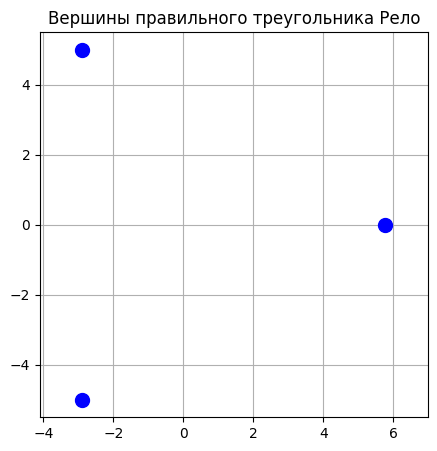

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.axis('equal')
plt.title('Вершины правильного треугольника Рело')
plt.grid(True)

## Этап 2. Представление одной стороны треугольника Рело

Построим первую сторону треугольника Рело как дугу окружности радиуса `r` с центром в вершине `vertices[0]`.

In [ ]:
alpha = 2 * np.pi / n
beta = alpha / 2
angle = np.linspace(-beta / 2, beta / 2, N)

side0 = vertices[0] + r * np.transpose([np.cos(np.pi + angle), np.sin(np.pi + angle)])
side1 = vertices[1] + r * np.transpose([np.cos(np.pi + angle + alpha), np.sin(np.pi + angle + alpha)])
list_sides = [
    vertices[i] + r * np.transpose([
        np.cos(np.pi + angle + i * alpha),
        np.sin(np.pi + angle + i * alpha)
    ])
    for i in range(n)
]
sides = np.concatenate(list_sides)
side0.shape, side1.shape, sides.shape

((100, 2), (100, 2), (300, 2))

### Параметрическое описание стороны треугольника Рело

Для первой стороны: `x(θ) = vertices[0,0] + r cos(π + θ)`, `y(θ) = vertices[0,1] + r sin(π + θ)` при θ ∈ [-β/2, β/2].
Для i-й стороны: `x(θ) = vertices[i,0] + r cos(π + θ + i α)`, `y(θ) = vertices[i,1] + r sin(π + θ + i α)`.

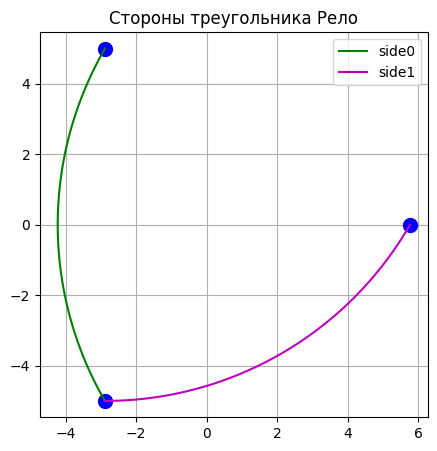

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(side0[:, 0], side0[:, 1], 'g-', label='side0')
plt.plot(side1[:, 0], side1[:, 1], 'm-', label='side1')
plt.axis('equal')
plt.title('Стороны треугольника Рело')
plt.legend()
plt.grid(True)

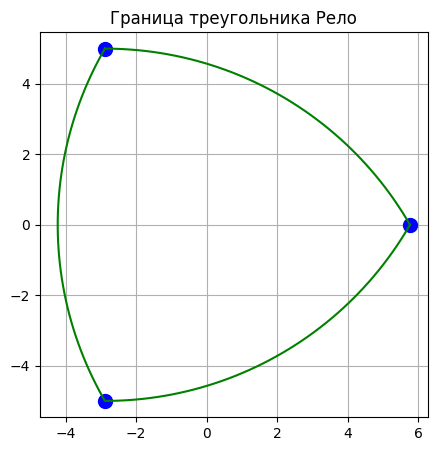

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(vertices[:, 0], vertices[:, 1], 'b.', markersize=20)
plt.plot(sides[:, 0], sides[:, 1], 'g-', label='sides')
plt.axis('equal')
plt.title('Граница треугольника Рело')
plt.grid(True)

## Задание 4.2 и 4.3. Функция `regular_polygon_Relo`

Создадим функцию, которая генерирует границу правильного n-угольника Рело для произвольных значений `n`, `center`, `r` и `N`.
Функция реализована прямо в этой тетрадке.

In [ ]:
import inspect


def regular_polygon_Relo(
    n: int = 3,
    center=np.array([0.0, 0.0]),
    r: float = 1.0,
    N: int = 100,
) -> np.ndarray:
    """Return the boundary coordinates of a regular Relo polygon.

    Parameters
    ----------
    n : int, optional
        Number of vertices of the regular polygon. Must be odd and > 2.
    center : array-like, optional
        Coordinates of the polygon center. Must be a 2-element vector.
    r : float, optional
        Width of the regular Relo polygon. Must be positive.
    N : int, optional
        Number of points used to describe one side. Must be a positive integer.

    Returns
    -------
    np.ndarray
        Array of shape (n * N, 2) with boundary coordinates of the regular Relo polygon.
    """
    center_arr = np.asarray(center, dtype=float)
    assert isinstance(n, int) and n > 2 and n % 2 == 1, (
        'n must be an odd integer greater than 2'
    )
    assert center_arr.shape == (2,), 'center must be a 2-element vector'
    assert isinstance(r, (int, float)) and r > 0, 'r must be a positive number'
    assert isinstance(N, int) and N > 0, 'N must be a positive integer'

    R = float(r) / (2 * np.cos(np.pi / (2 * n)))
    t = np.arange(0, 2 * np.pi, 2 * np.pi / n)
    vertices = center_arr + R * np.transpose([np.cos(t), np.sin(t)])

    alpha = 2 * np.pi / n
    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)

    list_sides = [
        vertices[i]
        + r * np.transpose(
            [
                np.cos(np.pi + angle + i * alpha),
                np.sin(np.pi + angle + i * alpha),
            ]
        )
        for i in range(n)
    ]

    sides = np.concatenate(list_sides)
    return sides

print('Function docstring:')
print(regular_polygon_Relo.__doc__)
print('Annotations:')
print(regular_polygon_Relo.__annotations__)
print('Source:')
print(inspect.getsource(regular_polygon_Relo))

Function docstring:
Return the boundary coordinates of a regular Relo polygon.

    Parameters
    ----------
    n : int, optional
        Number of vertices of the regular polygon. Must be odd and > 2.
    center : array-like, optional
        Coordinates of the polygon center. Must be a 2-element vector.
    r : float, optional
        Width of the regular Relo polygon. Must be positive.
    N : int, optional
        Number of points used to describe one side. Must be a positive integer.

    Returns
    -------
    np.ndarray
        Array of shape (n * N, 2) with boundary coordinates of the regular Relo polygon.
    
Annotations:
{'n': <class 'int'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}
Source:
def regular_polygon_Relo(
    n: int = 3,
    center=np.array([0.0, 0.0]),
    r: float = 1.0,
    N: int = 100,
) -> np.ndarray:
    """Return the boundary coordinates of a regular Relo polygon.

    Parameters
    ----------
    n : int, optional
  

In [ ]:
# Задание 4.4: тестирование функции regular_polygon_Relo

shapes = [
    regular_polygon_Relo(3, [0, 0], 10, 90),
    regular_polygon_Relo(5, [20, 0], 5, 80),
    regular_polygon_Relo(n=7, center=[-10, 10], r=8, N=70),
    regular_polygon_Relo(9, center=np.array([5.0, -5.0]), r=4.5, N=60),
    regular_polygon_Relo()
]

for i, shape in enumerate(shapes, start=1):
    print(f'Shape {i}:', shape.shape)

# Проверка контроля ошибок
try:
    regular_polygon_Relo(4, [0, 0], 5, 50)
except AssertionError as exc:
    print('Expected error for invalid n:', exc)

try:
    regular_polygon_Relo(3, [0, 0, 0], 5, 50)
except AssertionError as exc:
    print('Expected error for invalid center:', exc)

try:
    regular_polygon_Relo(3, [0, 0], -1, 50)
except AssertionError as exc:
    print('Expected error for invalid r:', exc)

try:
    regular_polygon_Relo(3, [0, 0], 5, 0)
except AssertionError as exc:
    print('Expected error for invalid N:', exc)

Shape 1: (270, 2)
Shape 2: (400, 2)
Shape 3: (490, 2)
Shape 4: (540, 2)
Shape 5: (300, 2)
Expected error for invalid n: n must be an odd integer greater than 2
Expected error for invalid center: center must be a 2-element vector
Expected error for invalid r: r must be a positive number
Expected error for invalid N: N must be a positive integer


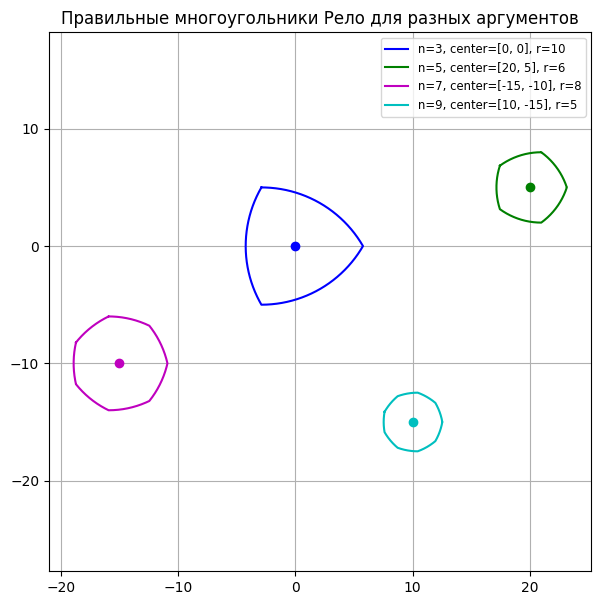

In [ ]:
plt.figure(figsize=(7, 7))
for n, center, r, N, color in [
    (3, [0, 0], 10, 120, 'b'),
    (5, [20, 5], 6, 100, 'g'),
    (7, [-15, -10], 8, 80, 'm'),
    (9, [10, -15], 5, 60, 'c'),
]:
    poly = regular_polygon_Relo(n, center, r, N)
    plt.plot(poly[:, 0], poly[:, 1], '-', label=f'n={n}, center={center}, r={r}', color=color)
    plt.plot(center[0], center[1], 'o', color=color)

plt.axis('equal')
plt.legend(loc='best', fontsize='small')
plt.title('Правильные многоугольники Рело для разных аргументов')
plt.grid(True)